In [1]:
import torch
from torch.profiler import profile, ProfilerActivity, record_function
from kdv import *

# Model Initialization Testing

In [2]:
# See if model can be initialized
INIT_PARAMS = dict(
    num_solitons             = 1,
    n_hidden_layers          = 4, 
    n_neurons_per_layer      = 32, 
    activation               = nn.Tanh,
    seed                     = 72, 
    verbose                  = True,
)
model = KDV(INIT_PARAMS)

Using device: cuda


# Loss Function Testing

First step is testing if these functions both run and output the expected results

In [3]:
from kdv_loss import *
from kdv_trainer import *

In [4]:
weights = {
    'w_ic': 10.7,
    'w_bc': 2.0
    #'w_pde': 20.0 #missing on purpose to test update works correctly
}

domain = setup_training_domain(1000, 100, 100, model.soliton_params)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Test loss dict
losses = init_loss_list()
print(f'The loss dict: {losses}')

#Test loss weights
loss_weights = init_loss_weights(device, init_weights=None)
print(f'The loss wieghts as default: {loss_weights}')
loss_weights = init_loss_weights(device, weights)
print(f'The loss wieghts with dict: {loss_weights}')
print(f'Loss weights device: {loss_weights.device} \n')

#loss_comps = torch.tensor([0.3, 4.3, 1.0], device=loss_weights.device) #dummy var, check loss_components function with proper neural network
loss_comps = loss_components(model.neural_net, domain=domain)
total_loss = torch.dot(loss_weights, loss_comps)
#make sure that the dot operator works as intended
print(f'Total loss: {total_loss}')

The loss dict: {'total': [], 'initial': [], 'boundary': [], 'pde': []}
The loss wieghts as default: tensor([1., 1., 1.], device='cuda:0')
The loss wieghts with dict: tensor([10.7000,  2.0000,  1.0000], device='cuda:0')
Loss weights device: cuda:0 

Total loss: 0.9233183264732361


/home/jairdan/miniconda3/envs/soliton-pinns/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


# Train Function Testing

In [5]:
#See if model can be trained
TRAIN_PARAMS = dict(
    adam_epochs              = 1000,
    lbfgs_epochs             = 1200,
    verbose_step             = 100,
    n_collocation            = 50000, 
    n_initial                = 30000,  
    n_boundary               = 10000,    
    adam_lr                  = 1e-3,   
    lbfgs_lr                 = 1.0,    
    lbfgs_history_size       = 100,  
    lbfgs_version            = '',
    adaptive_sampling        = False,
    logging                  = True
)

TRAIN_WEIGHTS = dict(
    w_ic                     = 5.0,    
    w_bc                     = 1.0,    
    w_pde                    = 15.0,
)

training_stats = model.train(TRAIN_PARAMS, TRAIN_WEIGHTS)

/home/jairdan/soliton-pinns/models_refactor/kdv/kdv_loss.py:143: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses['total'].append(float(total_loss))


Weighted losses [start]: IC=3.540e-01 | BC=8.423e-02 | PDE=8.978e-02
Starting Adam optimization...
[gpu mem] train start               alloc   730.9 MB  reserved   820.0 MB  peak   730.9 MB
Adam - Epoch 0/1000, Total Loss: 5.280356e-01
Adam - Epoch 100/1000, Total Loss: 7.871397e-03
Adam - Epoch 200/1000, Total Loss: 3.313881e-03
Adam - Epoch 300/1000, Total Loss: 1.441954e-03
Adam - Epoch 400/1000, Total Loss: 6.763433e-04
Adam - Epoch 500/1000, Total Loss: 3.746998e-04
Adam - Epoch 600/1000, Total Loss: 2.398223e-04
Adam - Epoch 700/1000, Total Loss: 1.744231e-04
Adam - Epoch 800/1000, Total Loss: 1.396990e-04
Adam - Epoch 900/1000, Total Loss: 1.188207e-04
Adam - Epoch 999/1000, Total Loss: 1.046937e-04
[gpu mem] after Adam                alloc    32.6 MB  reserved  1584.0 MB  peak  1445.1 MB

Starting L-BFGS optimization...
L-BFGS - Iteration 1/1200, Total Loss: 1.045150e-04
L-BFGS - Iteration 101/1200, Total Loss: 3.956154e-05
L-BFGS - Iteration 201/1200, Total Loss: 1.676016e-05


# Testing Function Testing

In [6]:
model.test(1000, 1000, 'absolute-normalized')

absolute-normalized error metrics:
Mean: 1.199342e-03
Maximum: 2.362875e-02


ErrorStats(mae=0.0011993420775979757, max_error=0.023628754541277885, error=tensor([[8.7196e-05, 8.1815e-05, 7.6912e-05,  ..., 8.5712e-05, 8.9980e-05,
         9.3585e-05],
        [8.6557e-05, 8.1948e-05, 7.6604e-05,  ..., 8.1370e-05, 8.5123e-05,
         8.9538e-05],
        [8.6067e-05, 8.0832e-05, 7.6186e-05,  ..., 7.6808e-05, 8.0119e-05,
         8.3578e-05],
        ...,
        [1.8221e-04, 1.8074e-04, 1.7831e-04,  ..., 3.1514e-04, 3.2176e-04,
         3.2874e-04],
        [1.8177e-04, 1.7979e-04, 1.7714e-04,  ..., 3.1252e-04, 3.1869e-04,
         3.2571e-04],
        [1.8060e-04, 1.7817e-04, 1.7559e-04,  ..., 3.0982e-04, 3.1606e-04,
         3.2220e-04]]))

# Visualizer Function Testing

In [7]:
import matplotlib.pyplot as plt

Losses

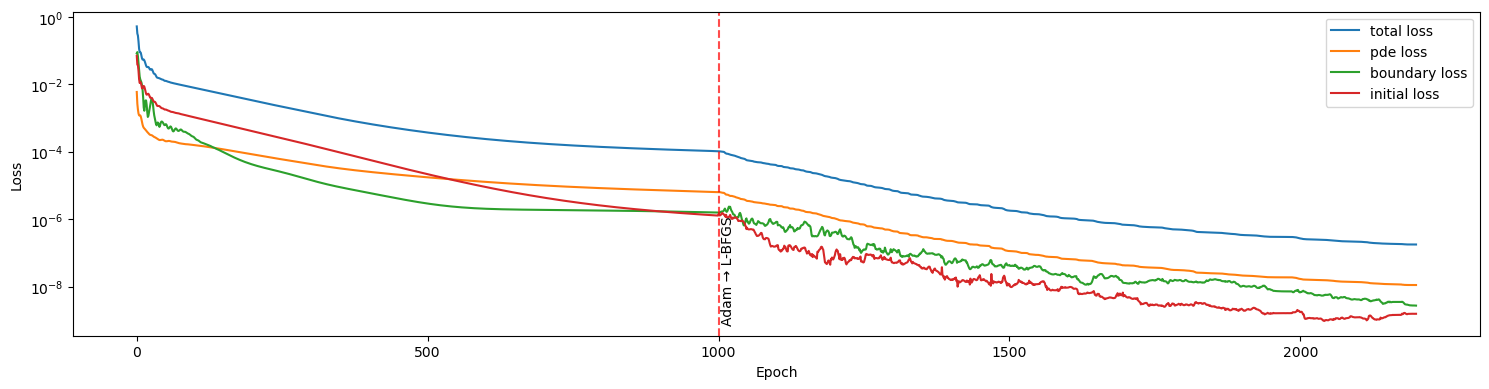

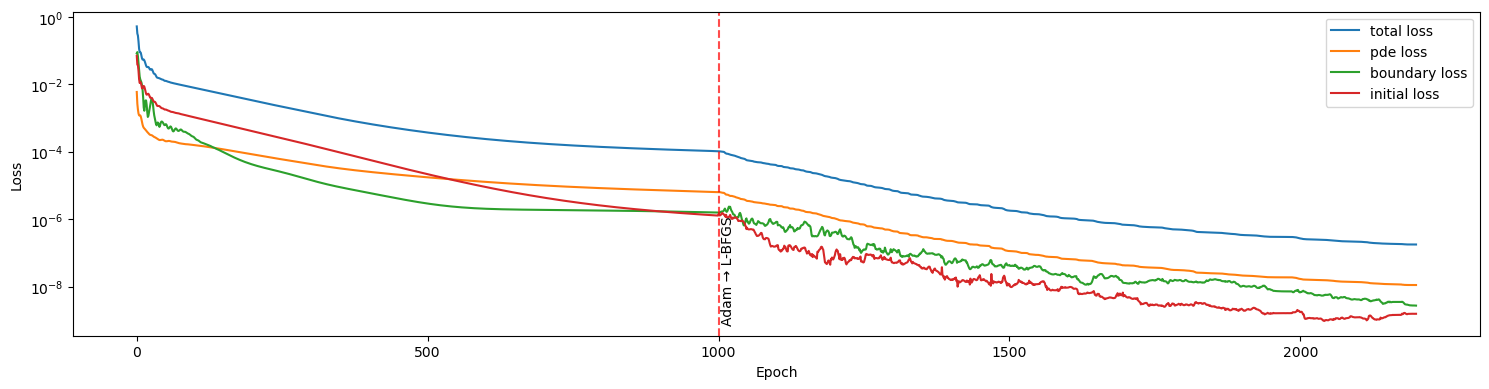

In [8]:
model.plot_losses(training_stats)

Profiles

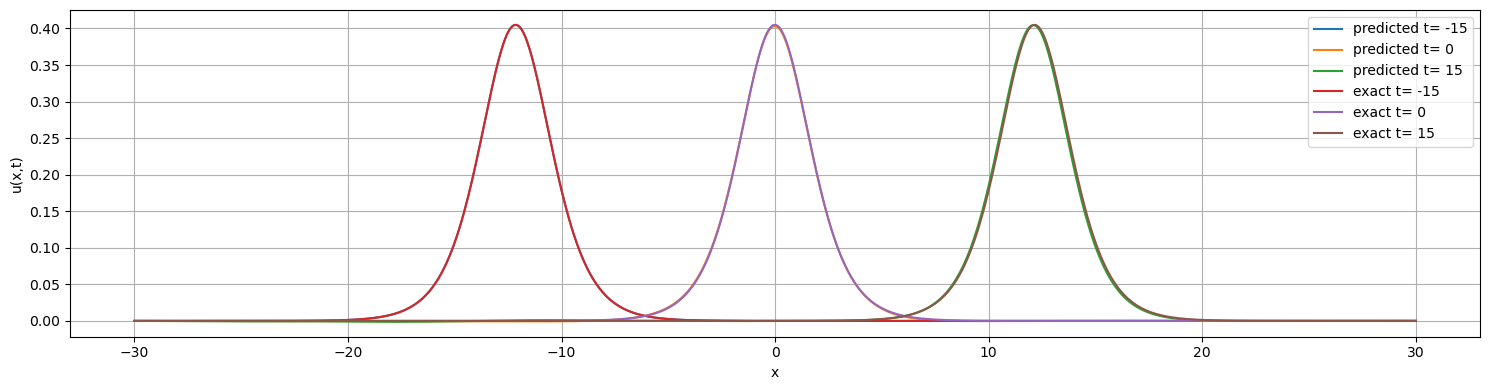

In [9]:
plot = model.plot_profiles([-15, 0, 15], ('predicted', 'exact'))

Spacetime

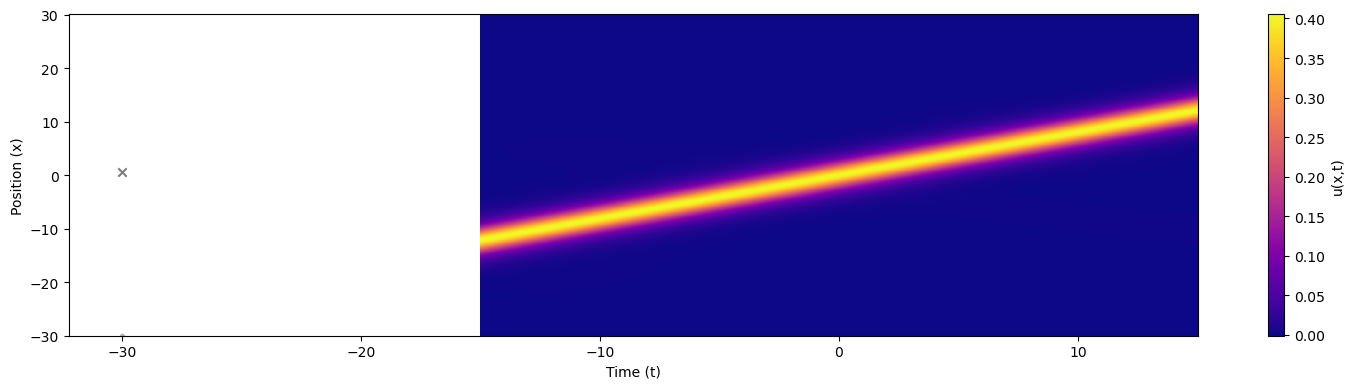

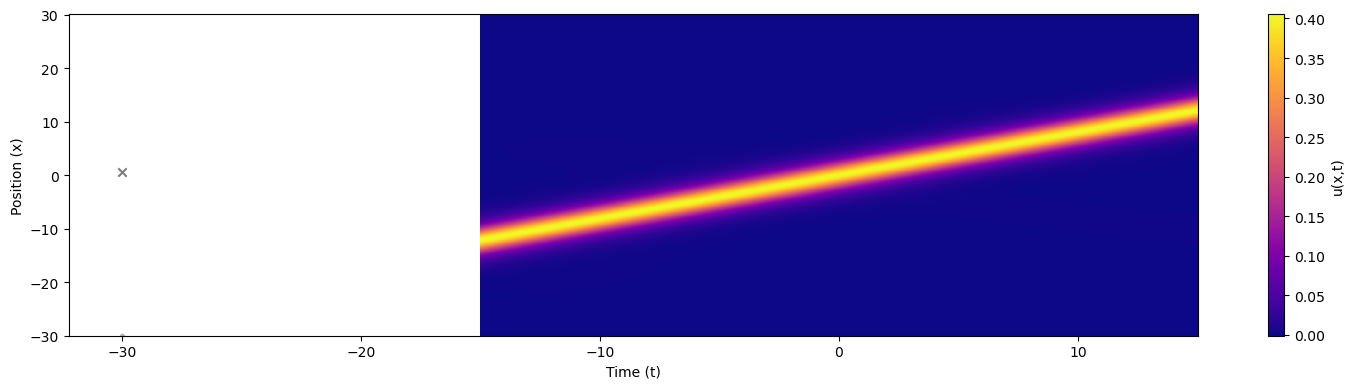

In [16]:
from kdv_trainer import setup_training_domain

training_domain = setup_training_domain(50000, 30000, 10000, model.soliton_params)
model.plot_spacetime(scatter_which=('pde', 'boundary', 'initial'), training_domain=training_domain)

# Function Profiling

In [11]:
"""
import torch
from torch.profiler import profile, ProfilerActivity, record_function
from kdv import *

TRAIN_PARAMS = dict(
    adam_epochs              = 1000,
    verbose_step             = 100,
    n_collocation            = 50000, 
    n_initial                = 30000,  
    n_boundary               = 10000,    
    adam_lr                  = 1e-3,   
    lbfgs_lr                 = 1.0,    
    lbfgs_history_size       = 100,  
    lbfgs_version            = 'old',
    adaptive_sampling        = False,   
)

TRAIN_WEIGHTS = dict(
    w_ic                     = 5.0,    
    w_bc                     = 1.0,    
    w_pde                    = 15.0,
)

INIT_PARAMS = dict(
    num_solitons             = 1,
    n_hidden_layers          = 4, 
    n_neurons_per_layer      = 32, 
    activation               = nn.Tanh,
    seed                     = 42, 
    verbose                  = True,
)
"""

"\nimport torch\nfrom torch.profiler import profile, ProfilerActivity, record_function\nfrom kdv import *\n\nTRAIN_PARAMS = dict(\n    adam_epochs              = 1000,\n    verbose_step             = 100,\n    n_collocation            = 50000, \n    n_initial                = 30000,  \n    n_boundary               = 10000,    \n    adam_lr                  = 1e-3,   \n    lbfgs_lr                 = 1.0,    \n    lbfgs_history_size       = 100,  \n    lbfgs_version            = 'old',\n    adaptive_sampling        = False,   \n)\n\nTRAIN_WEIGHTS = dict(\n    w_ic                     = 5.0,    \n    w_bc                     = 1.0,    \n    w_pde                    = 15.0,\n)\n\nINIT_PARAMS = dict(\n    num_solitons             = 1,\n    n_hidden_layers          = 4, \n    n_neurons_per_layer      = 32, \n    activation               = nn.Tanh,\n    seed                     = 42, \n    verbose                  = True,\n)\n"

In [12]:
"""
model = KDV(INIT_PARAMS)

def run():
    #add the sequence of loss function calls you want to run here
    return

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], 
    record_shapes=True, 
    profile_memory=True,
    with_modules=True,
    acc_events=True
) as p:
    run()
"""

'\nmodel = KDV(INIT_PARAMS)\n\ndef run():\n    #add the sequence of loss function calls you want to run here\n    return\n\nwith profile(\n    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], \n    record_shapes=True, \n    profile_memory=True,\n    with_modules=True,\n    acc_events=True\n) as p:\n    run()\n'